# MNIST Classification: Deep Ensembles vs MC-dropout

Reproduction of Figure 2(a) of Lakshminarayanan et al. (2017).
We train an MLP classifier on MNIST and compare deep ensembles to
MC-dropout in terms of classification error, NLL, and Brier score,
as a function of M (number of networks in the ensemble or number
of MC-dropout samples).

Setup: MLP with 3 hidden layers of 200 units, ReLU and batch
normalization. Adam, learning rate 1e-3, batch size 100, 10 epochs.
The trained ensemble is saved to disk and will be reused in the next notebook for the out-of-distribution detection experiment.

In [1]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision
!{sys.executable} -m pip install torch torchvision

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
    --------------------------------------- 1.8/123.0 MB 16.4 MB/s eta 0:00:08
   - -------------------------------------- 5.5/123.0 MB 19.8 MB/s eta 0:00:06
   --- ------------------------------------ 10.0/123.0 MB 18.8 MB/s eta 0:00:07
   ---- ----------------------------------- 15.2/123.0 MB 20.9 MB/s eta 0:00:06
   ------ --------------------------------- 18.6/123.0 MB 20.0 MB/s eta 0:00:06
   ------- -------------------------------- 22.3/123.0 MB 19.4 MB/s eta 0:00:06
   -------- ------------------------------- 26.2/123.0 MB 19.3 MB/s eta 0:00:06
   --------- ------------------------------ 29.6/123.0 MB 18.9 MB/s eta 0:00:05
   ---------- ----------------------------- 33.0/123.0 


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data

MNIST: 60k training images, 10k test images, 28x28 grayscale.
Flattened to 784-d vectors and normalized to [0, 1].

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),       # already in [0, 1]
    transforms.Lambda(lambda t: t.view(-1)),
])

train_set = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
test_set  = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=100, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=1000, shuffle=False)

print(f"Train: {len(train_set)}  Test: {len(test_set)}")

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 324kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.22MB/s]

Train: 60000  Test: 10000


## Models

Two architectures with identical capacity. `MLP` is used for the
deep ensemble. `DropoutMLP` adds a dropout layer (p=0.1) after each
ReLU, used for the MC-dropout baseline.

In [4]:
class MLP(nn.Module):
    """Standard MLP for the deep ensemble."""

    def __init__(self, in_dim=784, hidden_dim=200, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class DropoutMLP(nn.Module):
    """Same MLP with dropout after each ReLU, used for MC-dropout."""

    def __init__(self, in_dim=784, hidden_dim=200, n_classes=10, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)

## Training

Standard supervised training with cross-entropy loss. Each network
takes around 1-2 minutes on CPU.

In [5]:
def train_network(model_class, n_epochs=10, lr=1e-3, seed=0, verbose=False):
    torch.manual_seed(seed)
    model = model_class().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * x.size(0)
        if verbose:
            print(f"  epoch {epoch+1}: loss={total_loss/len(train_set):.4f}")

    return model

## Predictions

For the deep ensemble, we average the softmax outputs of the M
networks at test time. For MC-dropout, we keep dropout active at test time and average the softmax over M stochastic forward passes from a single network. Batch normalization is kept in eval mode in both cases.

In [6]:
@torch.no_grad()
def predict_ensemble(models, loader):
    """Average softmax over an ensemble of M networks."""
    all_probs, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        probs_batch = torch.zeros(x.size(0), 10, device=device)
        for model in models:
            model.eval()
            probs_batch += F.softmax(model(x), dim=1)
        probs_batch /= len(models)
        all_probs.append(probs_batch.cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


@torch.no_grad()
def predict_mc_dropout(model, loader, M):
    """Average softmax over M stochastic forward passes with dropout on."""
    # Enable dropout but keep batch norm in eval mode
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

    all_probs, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        probs_batch = torch.zeros(x.size(0), 10, device=device)
        for _ in range(M):
            probs_batch += F.softmax(model(x), dim=1)
        probs_batch /= M
        all_probs.append(probs_batch.cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

## Metrics

Classification error in percent, negative log-likelihood, and Brier score, computed on the original 10-class outputs.

In [7]:
def compute_metrics(probs, labels):
    preds = probs.argmax(axis=1)
    err = 100.0 * (preds != labels).mean()

    eps = 1e-12
    nll = -np.log(probs[np.arange(len(labels)), labels] + eps).mean()

    one_hot = np.zeros_like(probs)
    one_hot[np.arange(len(labels)), labels] = 1.0
    brier = ((probs - one_hot) ** 2).sum(axis=1).mean()

    return err, nll, brier

## Train the ensemble

We train 10 independent networks for the deep ensemble and a single dropout network for MC-dropout. At evaluation time, the ensemble is evaluated for several values of M by taking the first M members.

In [8]:
M_MAX = 10
N_EPOCHS = 10

# Deep ensemble: M_MAX independent networks
ensemble = []
for m in range(M_MAX):
    print(f"Training ensemble member {m+1}/{M_MAX}...")
    model = train_network(MLP, n_epochs=N_EPOCHS, seed=SEED + m)
    ensemble.append(model)

# MC-dropout: a single network
print("Training MC-dropout network...")
mc_model = train_network(DropoutMLP, n_epochs=N_EPOCHS, seed=SEED)

print("Done.")

Training ensemble member 1/10...
Training ensemble member 2/10...
Training ensemble member 3/10...
Training ensemble member 4/10...
Training ensemble member 5/10...
Training ensemble member 6/10...
Training ensemble member 7/10...
Training ensemble member 8/10...
Training ensemble member 9/10...
Training ensemble member 10/10...
Training MC-dropout network...
Done.


In [9]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

for m, model in enumerate(ensemble):
    torch.save(model.state_dict(), MODELS_DIR / f"ensemble_{m}.pt")
torch.save(mc_model.state_dict(), MODELS_DIR / "mc_dropout.pt")

print(f"Saved {M_MAX} ensemble members and the MC-dropout model to {MODELS_DIR}/")

Saved 10 ensemble members and the MC-dropout model to models/


## Evaluation as a function of M

For each M, we evaluate the ensemble using its first M members and MC-dropout using M stochastic forward passes from the dropout network, and report the three metrics.

In [10]:
M_VALUES = [1, 2, 3, 5, 7, 10]
results = {"ensemble": [], "mc_dropout": []}

for M in M_VALUES:
    # Deep ensemble: take the first M members
    probs, labels = predict_ensemble(ensemble[:M], test_loader)
    err, nll, brier = compute_metrics(probs, labels)
    results["ensemble"].append((M, err, nll, brier))

    # MC-dropout: M stochastic forward passes
    probs, labels = predict_mc_dropout(mc_model, test_loader, M=M)
    err_d, nll_d, brier_d = compute_metrics(probs, labels)
    results["mc_dropout"].append((M, err_d, nll_d, brier_d))

    print(f"M={M:2d}  Ensemble: err={err:.2f}%  nll={nll:.3f}  brier={brier:.4f}   "
          f"MC-dropout: err={err_d:.2f}%  nll={nll_d:.3f}  brier={brier_d:.4f}")

M= 1  Ensemble: err=2.07%  nll=0.074  brier=0.0313   MC-dropout: err=2.15%  nll=0.073  brier=0.0323
M= 2  Ensemble: err=1.51%  nll=0.051  brier=0.0239   MC-dropout: err=1.96%  nll=0.067  brier=0.0313
M= 3  Ensemble: err=1.43%  nll=0.049  brier=0.0229   MC-dropout: err=1.87%  nll=0.062  brier=0.0290
M= 5  Ensemble: err=1.34%  nll=0.043  brier=0.0205   MC-dropout: err=1.81%  nll=0.061  brier=0.0278
M= 7  Ensemble: err=1.27%  nll=0.040  brier=0.0196   MC-dropout: err=1.75%  nll=0.058  brier=0.0275
M=10  Ensemble: err=1.29%  nll=0.040  brier=0.0192   MC-dropout: err=1.68%  nll=0.057  brier=0.0266


## Plot

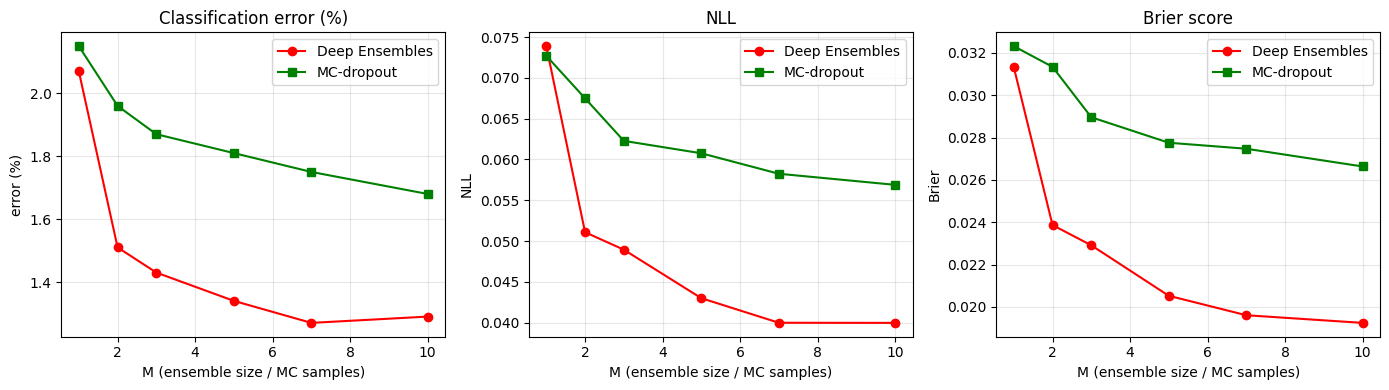

In [11]:
ens = np.array(results["ensemble"])     # (n_values, 4): M, err, nll, brier
mcd = np.array(results["mc_dropout"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ["Classification error (%)", "NLL", "Brier score"]
ylabels = ["error (%)", "NLL", "Brier"]

for i, (ax, title, ylabel) in enumerate(zip(axes, titles, ylabels)):
    col = i + 1   # 1=err, 2=nll, 3=brier
    ax.plot(ens[:, 0], ens[:, col], "o-", color="red",  label="Deep Ensembles")
    ax.plot(mcd[:, 0], mcd[:, col], "s-", color="green", label="MC-dropout")
    ax.set_xlabel("M (ensemble size / MC samples)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("figures/mnist_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

The trained models are saved in `models/` and will be reused in the next notebook for the out-of-distribution detection experiment.